Device: cuda
Loaded 335 keys. Missing: 0 Unexpected: 0


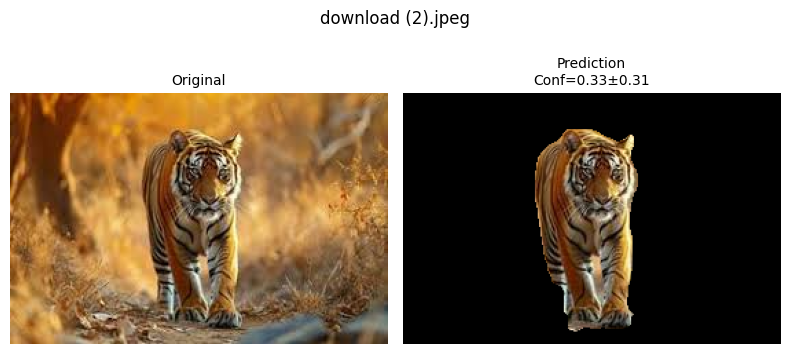

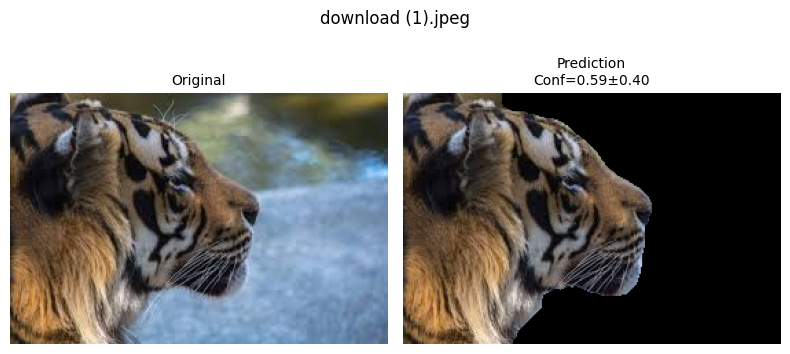

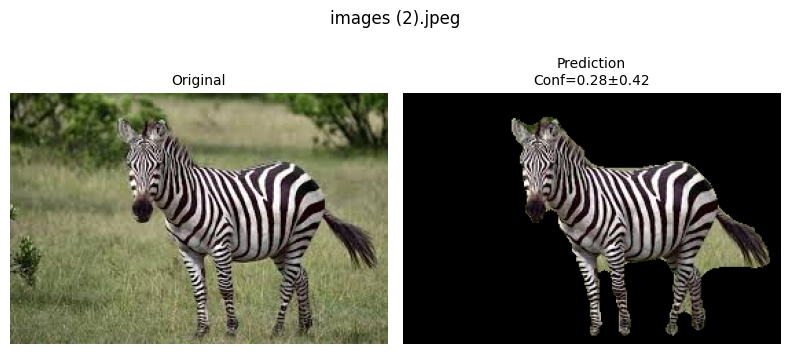

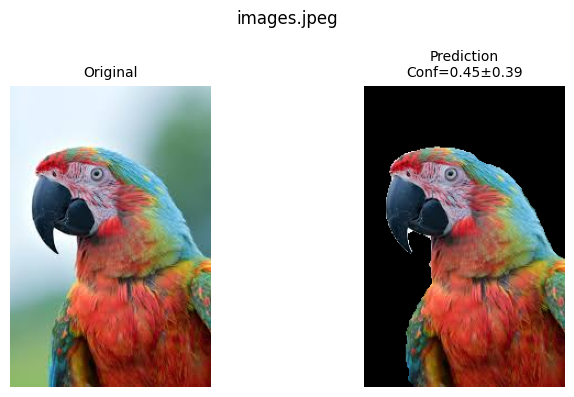

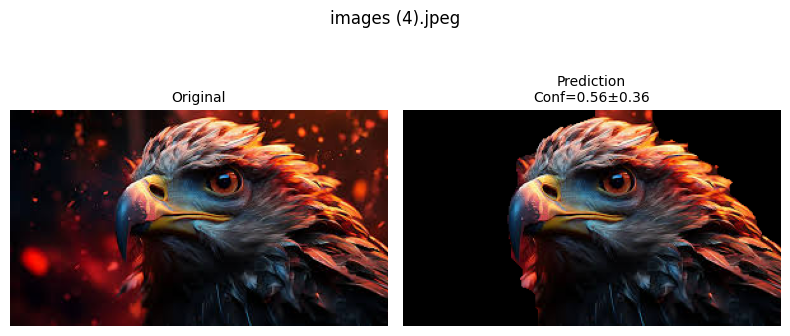

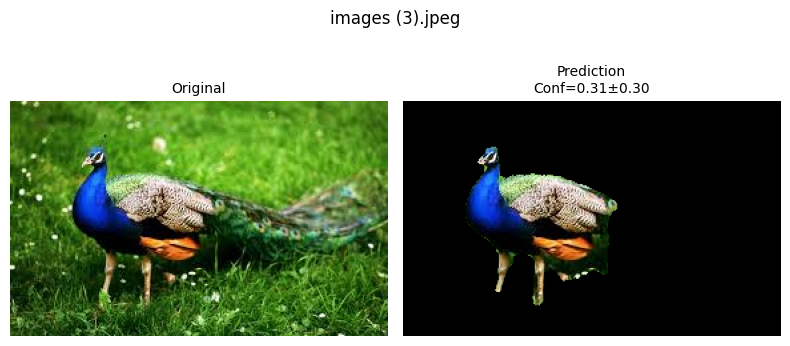

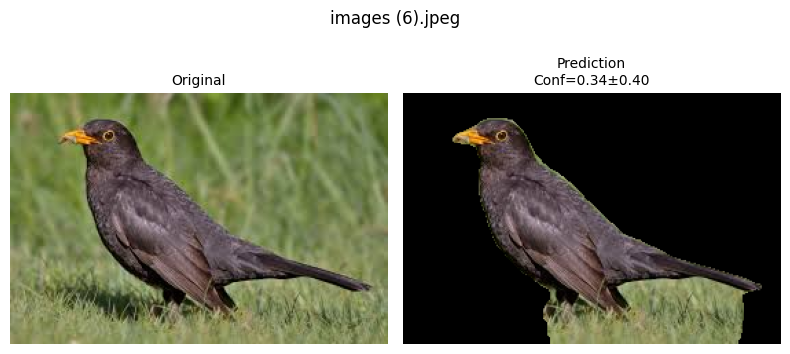

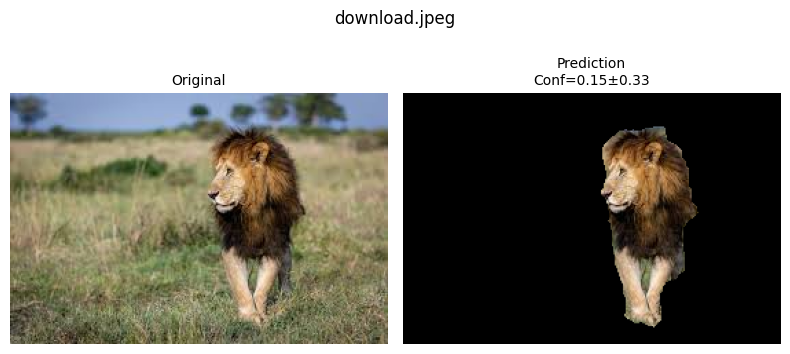

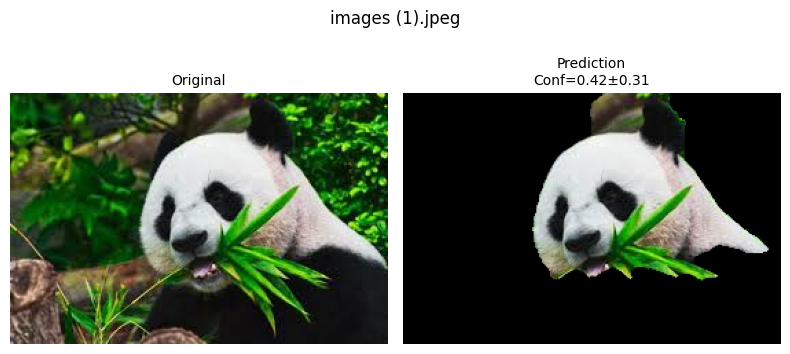

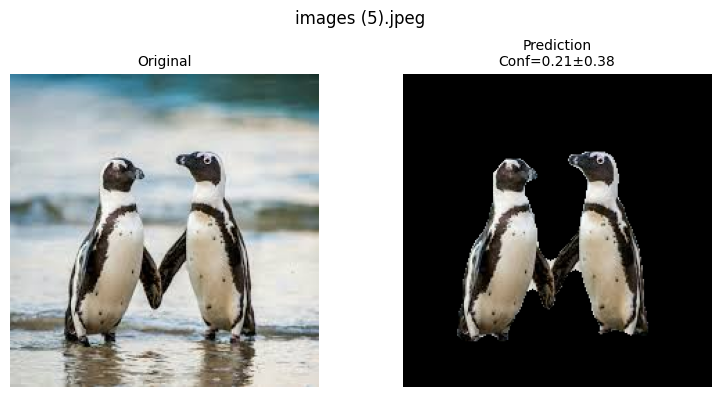

In [10]:
# inference_unseen_all_jupyter.ipynb cell

import os, random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.segmentation import deeplabv3_resnet101
import torchvision.transforms.functional as TF

# ---------------------- CONFIG ----------------------
MODEL_PATH = r"C:\Users\rahul\Downloads\Telegram Desktop\deeplabv3_resnet101_stage3_full.pth"
IMAGE_DIR  = r"C:\Users\rahul\Downloads\infosys project\unseen images"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
INPUT_SIZE = 640
# Enhanced TTA configuration
TTA_SCALES = [0.5, 0.75, 1.0, 1.25, 1.5]  # More scales for better coverage
DO_FLIP = True
GRABCUT_ITERS = 8  # Increased iterations for better refinement
SEED = 42           # fixed seed -> same random images each run
NUM_SAMPLES = 20    # visualize only 20 at a time (random subset)

print("Device:", DEVICE)

# ---------------------- model helpers ----------------------
def replace_bn_with_gn(module, num_groups=32):
    for name, child in list(module.named_children()):
        if isinstance(child, nn.BatchNorm2d):
            setattr(module, name, nn.GroupNorm(num_groups=num_groups, num_channels=child.num_features))
        else:
            replace_bn_with_gn(child, num_groups)

def build_model(num_classes=1):
    model = deeplabv3_resnet101(weights=None, aux_loss=False)
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    replace_bn_with_gn(model)
    return model

def safe_load_checkpoint_into_model(model, ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    sd = ckpt.get("state_dict", ckpt) if isinstance(ckpt, dict) else ckpt
    model_sd = model.state_dict()
    filtered = {k.replace("module.",""): v for k,v in sd.items() if k.replace("module.","") in model_sd and model_sd[k.replace("module.","")].shape==v.shape}
    msg = model.load_state_dict(filtered, strict=False)
    print(f"Loaded {len(filtered)} keys. Missing: {len(msg.missing_keys)} Unexpected: {len(msg.unexpected_keys)}")

model = build_model(num_classes=1)
safe_load_checkpoint_into_model(model, MODEL_PATH)
model.to(DEVICE).eval()

# ---------------------- preprocess ----------------------
def resize_keep_aspect_and_pad(pil_img, min_short=INPUT_SIZE, scale=1.0, pad_fill=(0,0,0), max_side=1280):
    w, h = pil_img.size
    base_scale = min_short / float(min(w, h))
    tw, th = int(w*base_scale*scale), int(h*base_scale*scale)
    if max(tw,th) > max_side:
        ratio = max_side / float(max(tw,th))
        tw, th = int(tw*ratio), int(th*ratio)
    img_resized = pil_img.resize((tw, th), Image.BILINEAR)
    S = max(tw, th)
    canvas = Image.new("RGB",(S,S), pad_fill)
    l,t = (S-tw)//2, (S-th)//2
    canvas.paste(img_resized,(l,t))
    return canvas,(l,t,tw,th,S)

def tensor_from_pil(img):
    t = TF.to_tensor(img)
    return TF.normalize(t, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]).unsqueeze(0)

def upsample_to(x,h,w): 
    return F.interpolate(x,size=(h,w),mode="bilinear",align_corners=False)

# ---------------------- IMPROVED POSTPROCESSING ----------------------
def improved_adaptive_threshold(prob_map):
    vals = prob_map.flatten()
    m = vals.mean()
    s = vals.std()
    
    # Strategy 1: Statistical approach
    stat_thresh = max(0.15, min(0.7, m + 0.3 * s))
    
    # Strategy 2: Percentile-based (more robust to outliers)
    p90 = np.percentile(vals, 90)
    p10 = np.percentile(vals, 10)
    percentile_thresh = p10 + 0.4 * (p90 - p10)
    
    # Strategy 3: Simplified histogram analysis
    hist, bins = np.histogram(vals, bins=128, range=(0, 1))
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Find weighted average of high probability regions
    high_prob_indices = hist > np.percentile(hist, 70)
    if np.any(high_prob_indices):
        high_prob_centers = bin_centers[high_prob_indices]
        high_prob_weights = hist[high_prob_indices]
        weighted_thresh = np.average(high_prob_centers, weights=high_prob_weights)
    else:
        weighted_thresh = 0.5
    
    # Combine all strategies
    final_thresh = (0.4 * stat_thresh + 0.4 * percentile_thresh + 0.2 * weighted_thresh)
    final_thresh = max(0.1, min(0.8, final_thresh))  # Keep within reasonable bounds
    
    return final_thresh, float(m), float(s)

def improved_morphology(mask):
    if np.sum(mask) == 0:
        return mask
        
    mask = (mask > 0).astype(np.uint8)
    h, w = mask.shape
    
    # Adaptive kernel sizes based on image size
    k_small = max(3, min(7, int(min(h, w) / 150)))
    k_medium = max(5, min(11, int(min(h, w) / 100)))
    
    # Ensure odd kernel sizes
    k_small = k_small + 1 if k_small % 2 == 0 else k_small
    k_medium = k_medium + 1 if k_medium % 2 == 0 else k_medium
    
    kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_small, k_small))
    kernel_medium = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_medium, k_medium))
    
    # Multi-scale morphological processing
    # First pass: clean small noise
    m = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_small, iterations=1)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel_small, iterations=1)
    
    # Second pass: connect nearby regions
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel_medium, iterations=2)
    
    # Keep multiple significant components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    
    if num_labels <= 1:
        return m
    
    areas = stats[1:, cv2.CC_STAT_AREA]
    if len(areas) == 0:
        return m
    
    max_area = np.max(areas)
    result = np.zeros_like(m)
    
    # Keep components that are at least 8% of the largest component
    for i in range(1, num_labels):
        if areas[i-1] >= max_area * 0.08:
            result[labels == i] = 1
    
    return result

def improved_grabcut_refine(orig, mask, prob_map, iters=8):
    if np.sum(mask) < 15:  # Too small to refine effectively
        return mask
        
    img = cv2.cvtColor(np.array(orig), cv2.COLOR_RGB2BGR)
    h, w = mask.shape
    
    # More sophisticated GrabCut initialization
    gc_mask = np.full((h, w), cv2.GC_PR_BGD, np.uint8)
    
    # High confidence foreground (definite objects)
    gc_mask[prob_map > 0.85] = cv2.GC_FGD
    
    # Medium confidence foreground (probable objects)
    gc_mask[(prob_map > 0.45) & (prob_map <= 0.85)] = cv2.GC_PR_FGD
    
    # Low confidence background
    gc_mask[(prob_map >= 0.15) & (prob_map <= 0.45)] = cv2.GC_PR_BGD
    
    # High confidence background (definite background)
    gc_mask[prob_map < 0.15] = cv2.GC_BGD
    
    # Ensure we have reasonable foreground areas
    fg_count = np.sum((gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD))
    bg_count = np.sum((gc_mask == cv2.GC_BGD) | (gc_mask == cv2.GC_PR_BGD))
    
    if fg_count < 30 or bg_count < 30:
        # Fallback: use simpler initialization based on original mask
        gc_mask[mask == 1] = cv2.GC_PR_FGD
        gc_mask[mask == 0] = cv2.GC_PR_BGD
    
    try:
        bgd_model = np.zeros((1, 65), np.float64)
        fgd_model = np.zeros((1, 65), np.float64)
        
        cv2.grabCut(img, gc_mask, None, bgd_model, fgd_model, iters, cv2.GC_INIT_WITH_MASK)
        
        # Combine definite and probable foreground
        refined_mask = np.where((gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD), 1, 0)
        return refined_mask.astype(np.uint8)
        
    except Exception as e:
        # print(f"GrabCut failed, using original mask: {e}")
        return mask

def run_one_pass(orig, scale=1.0, flip=False):
    canvas, (l, t, tw, th, S) = resize_keep_aspect_and_pad(orig, INPUT_SIZE, scale)
    if flip: 
        canvas = TF.hflip(canvas)
    inp = tensor_from_pil(canvas).to(DEVICE)
    with torch.no_grad():
        out = model(inp)["out"]
        out = upsample_to(out, S, S)
        p = torch.sigmoid(out)[0, 0].cpu().numpy()
    if flip: 
        p = np.fliplr(p)
    pc = p[t:t+th, l:l+tw]
    return cv2.resize(pc, (orig.width, orig.height), cv2.INTER_LINEAR)

# ---------------------- IMPROVED TTA PREDICT ----------------------
def enhanced_tta_predict(orig):
    H, W = orig.height, orig.width
    acc = np.zeros((H, W), np.float32)
    c = 0
    
    # Enhanced TTA with more scales
    for s in TTA_SCALES:
        for flip in [False, True] if DO_FLIP else [False]:
            prob_map = run_one_pass(orig, s, flip)
            acc += prob_map
            c += 1
    
    avg = acc / c
    
    # Improved thresholding
    thr, mc, sc = improved_adaptive_threshold(avg)
    mask = (avg > thr).astype(np.uint8)
    
    # Enhanced post-processing pipeline
    mask = improved_morphology(mask)
    mask = improved_grabcut_refine(orig, mask, avg)
    mask = improved_morphology(mask)  # Final cleanup
    
    return np.array(orig), (mask[..., None] * np.array(orig)).astype(np.uint8), mc, sc

# ---------------------- Run on ALL unseen images ----------------------
random.seed(SEED)
all_imgs = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(("jpg", "png", "jpeg"))]

# Pick only NUM_SAMPLES for visualization
sample_imgs = random.sample(all_imgs, min(NUM_SAMPLES, len(all_imgs)))

for fname in sample_imgs:
    path = os.path.join(IMAGE_DIR, fname)
    img = Image.open(path).convert("RGB")
    orig, res, mc, sc = enhanced_tta_predict(img)  # Use enhanced version
    
    # Same visualization format as before
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))  
    
    axs[0].imshow(orig)
    axs[0].set_title("Original", fontsize=10)
    axs[0].axis("off")

    axs[1].imshow(res)
    axs[1].set_title(f"Prediction\nConf={mc:.2f}±{sc:.2f}", fontsize=10)
    axs[1].axis("off")

    plt.suptitle(fname, fontsize=12)
    plt.tight_layout()
    plt.show()

Device: cuda
Loaded 335 keys. Missing: 0 Unexpected: 0


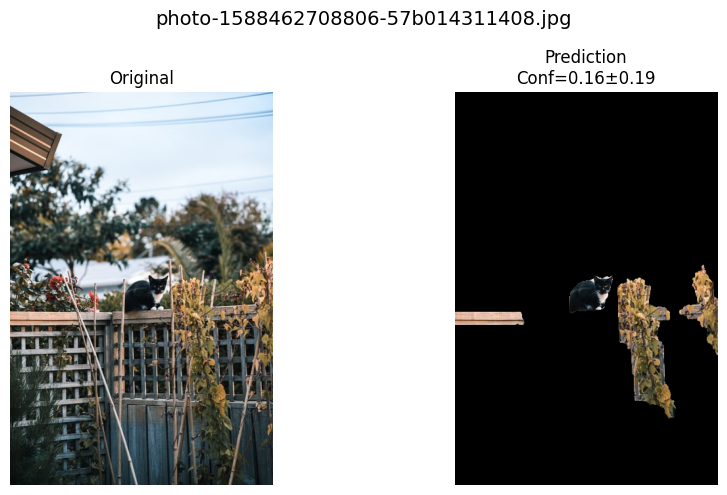

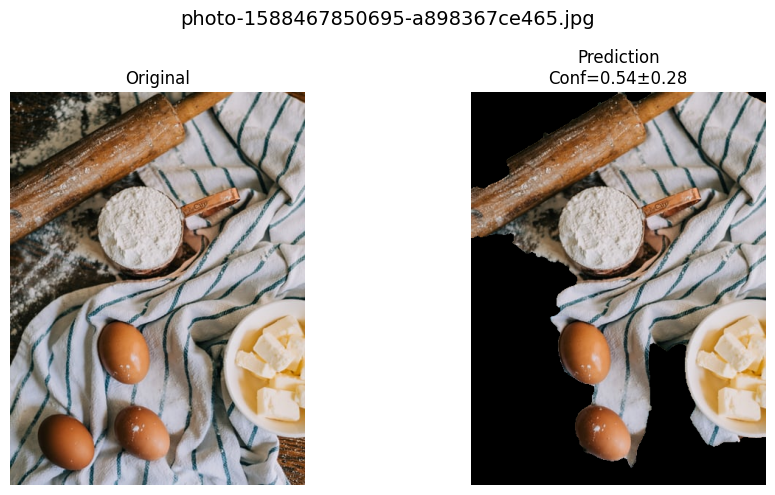

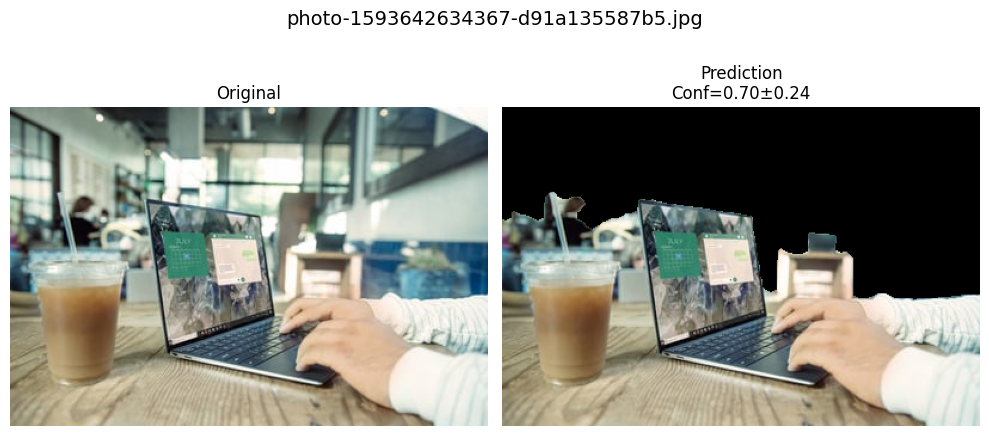

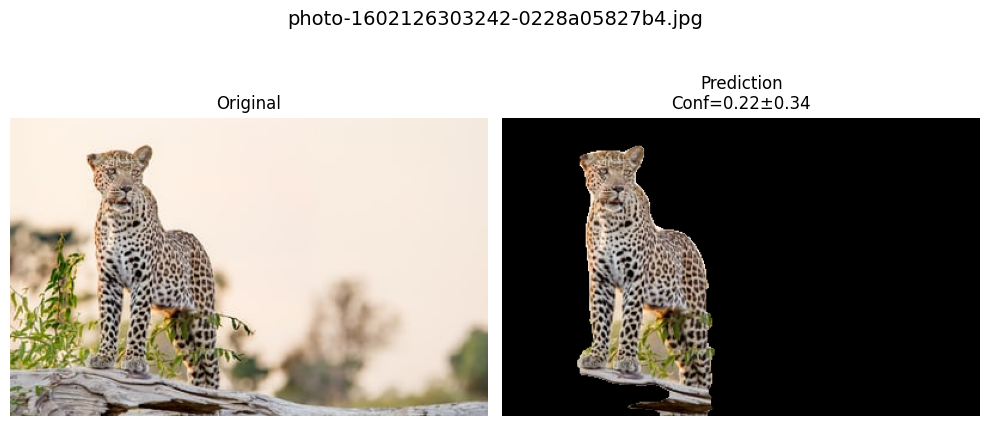

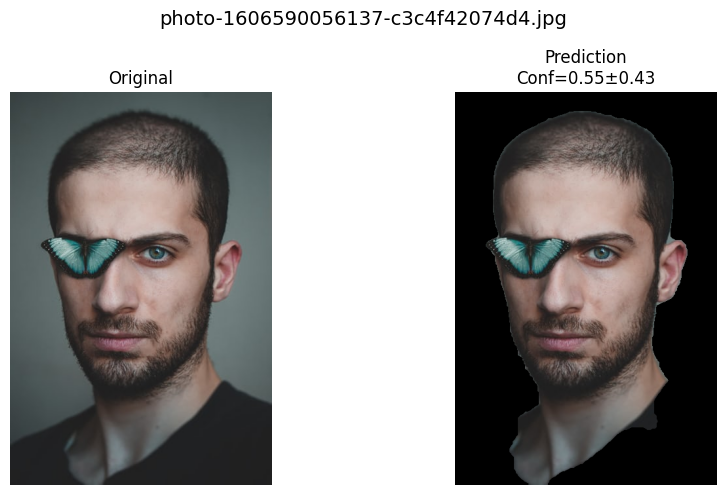

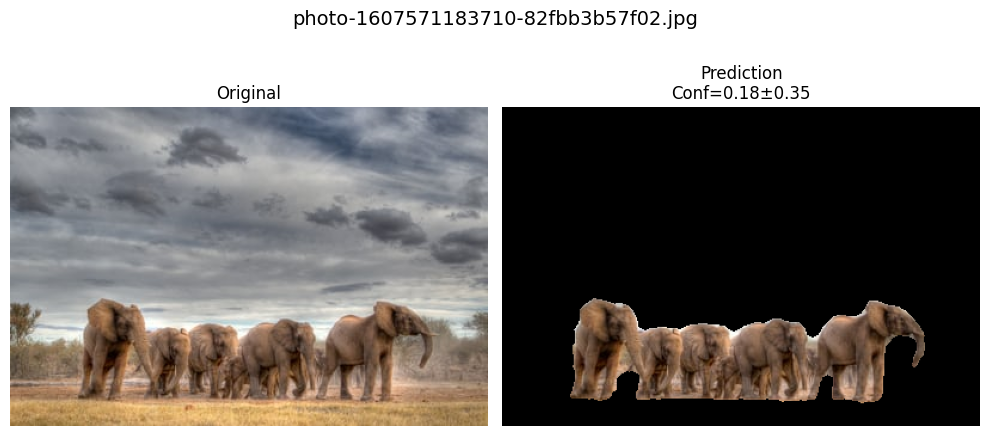

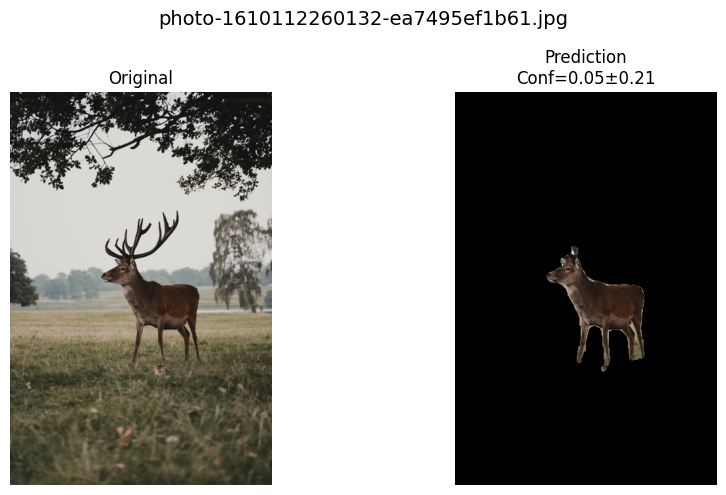

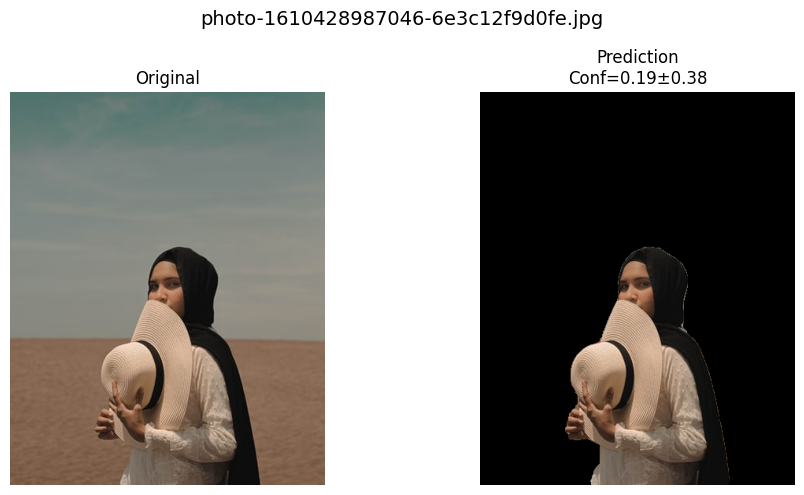

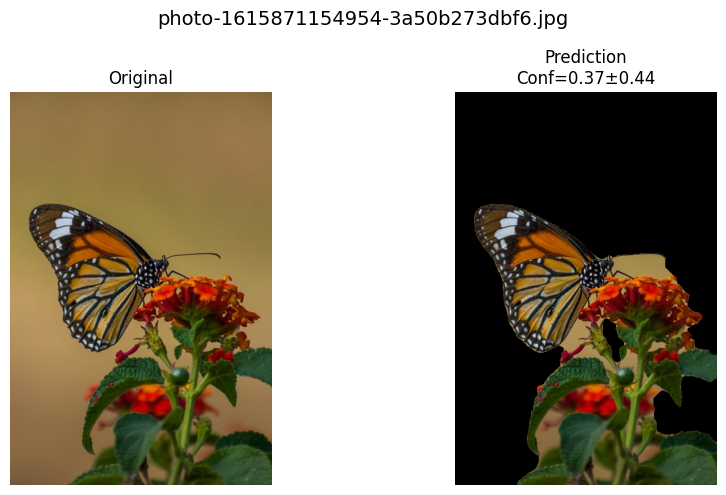

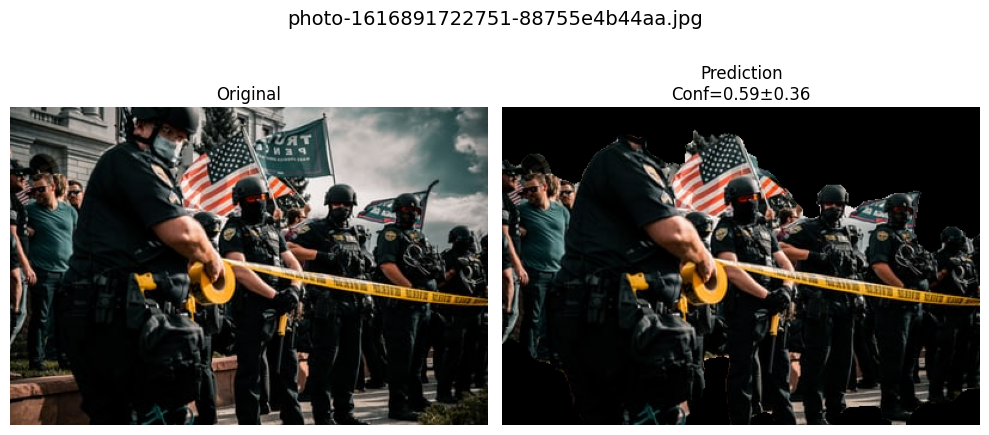

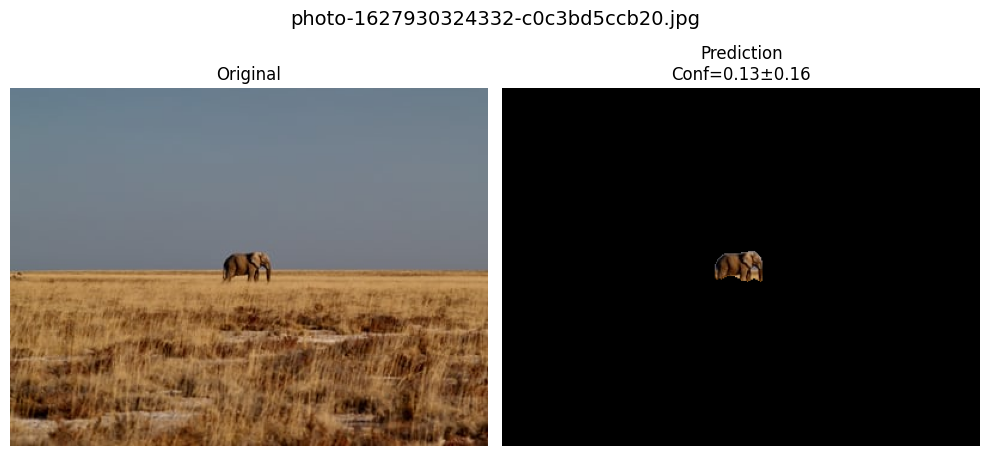

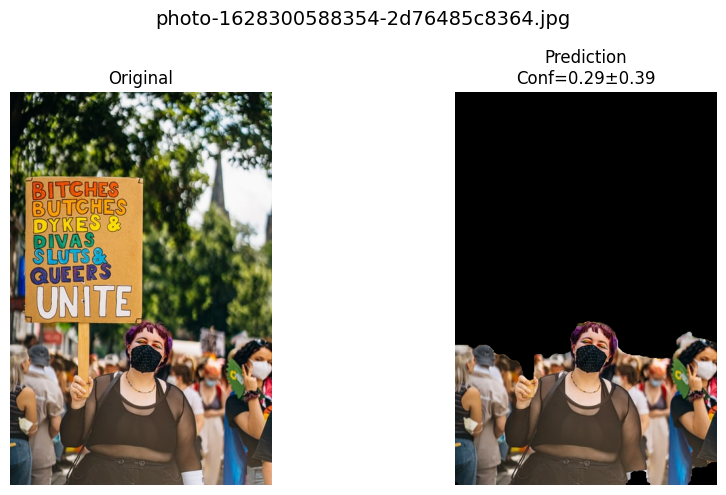

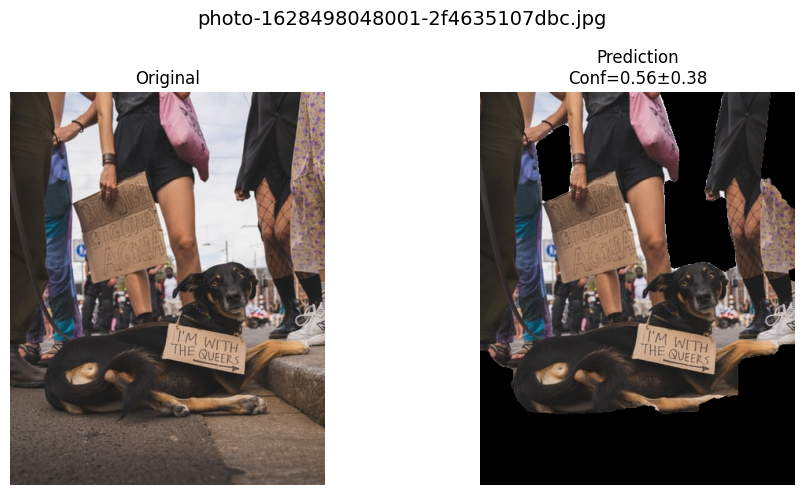

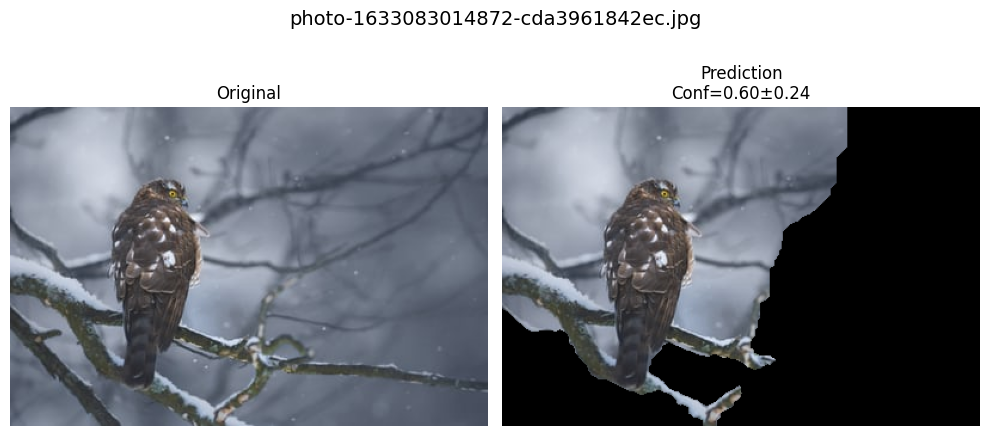

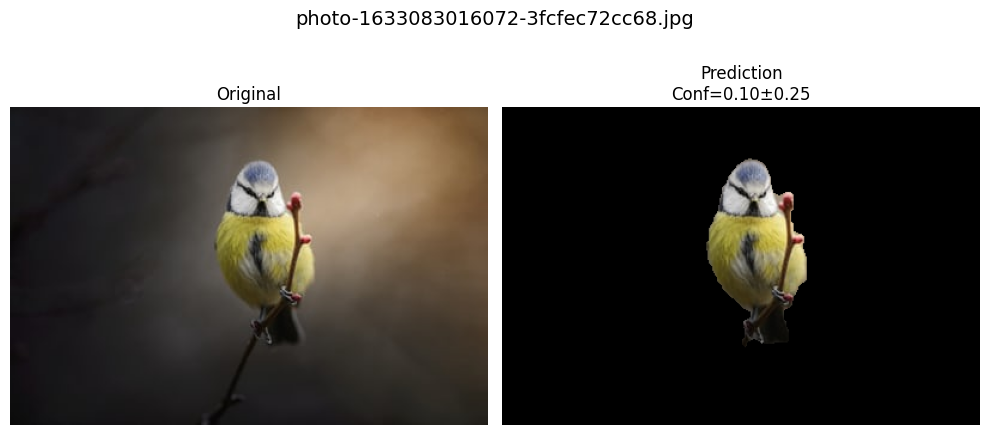

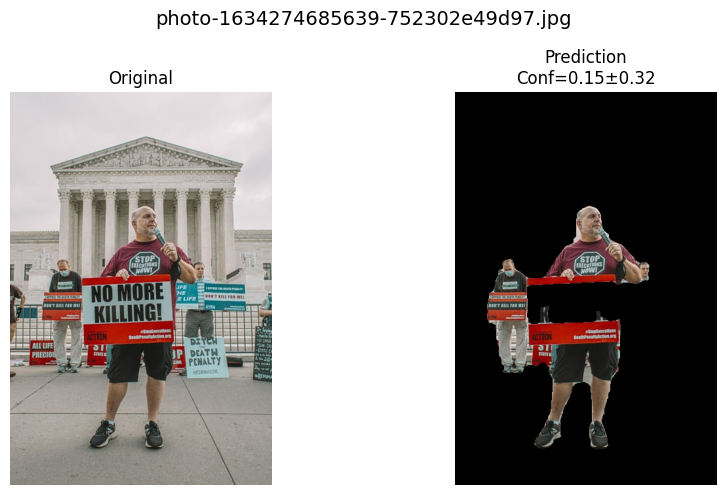

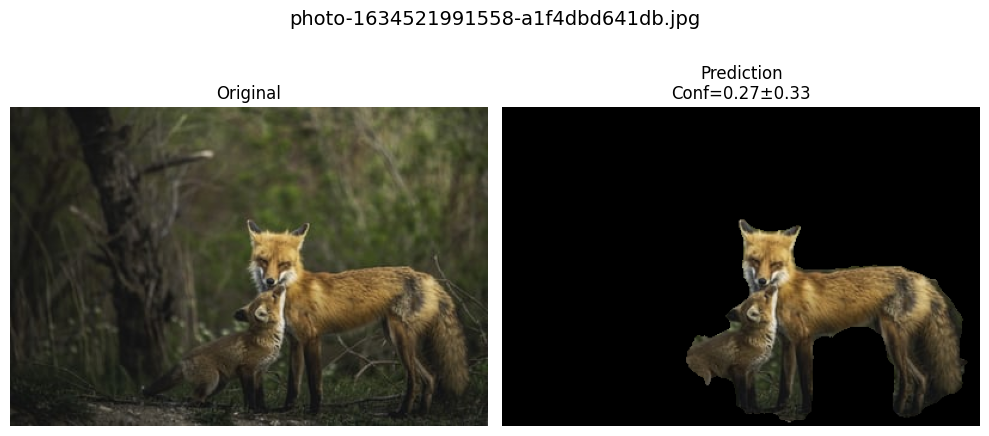

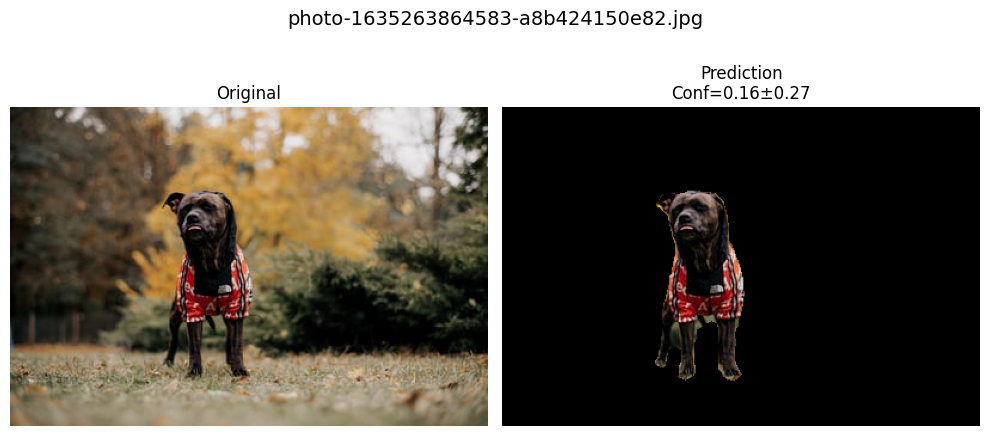

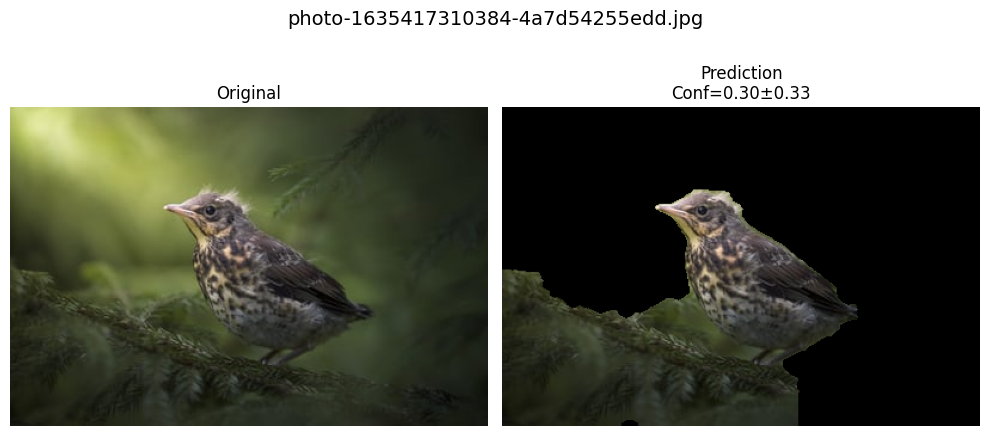

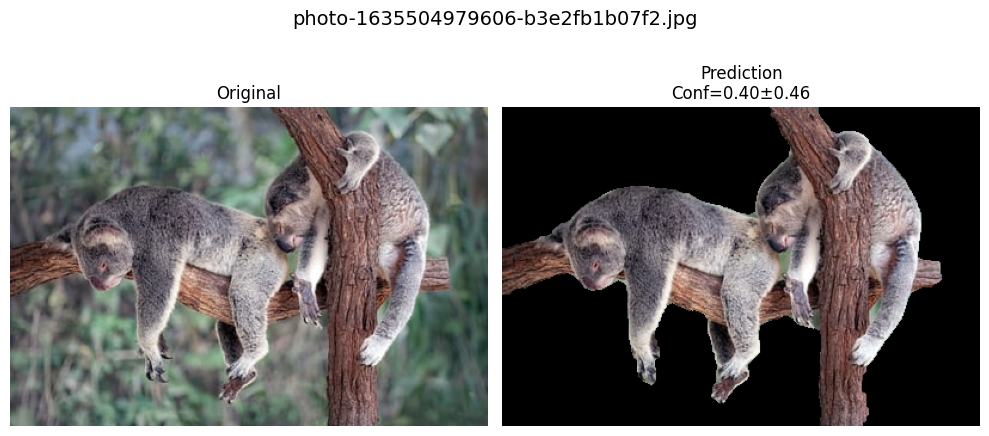

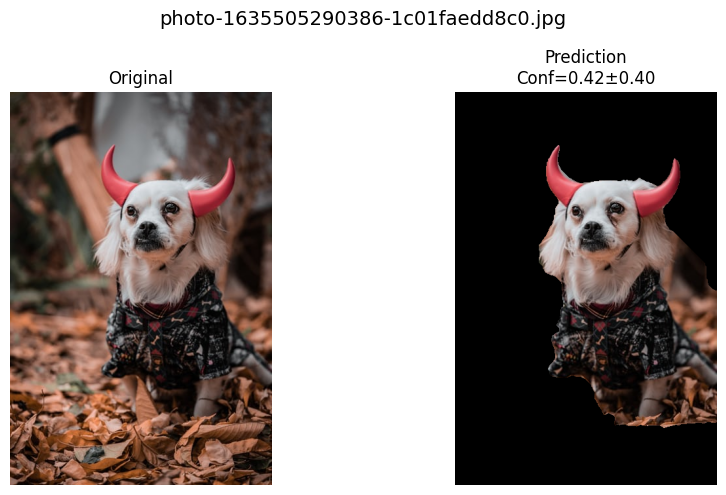

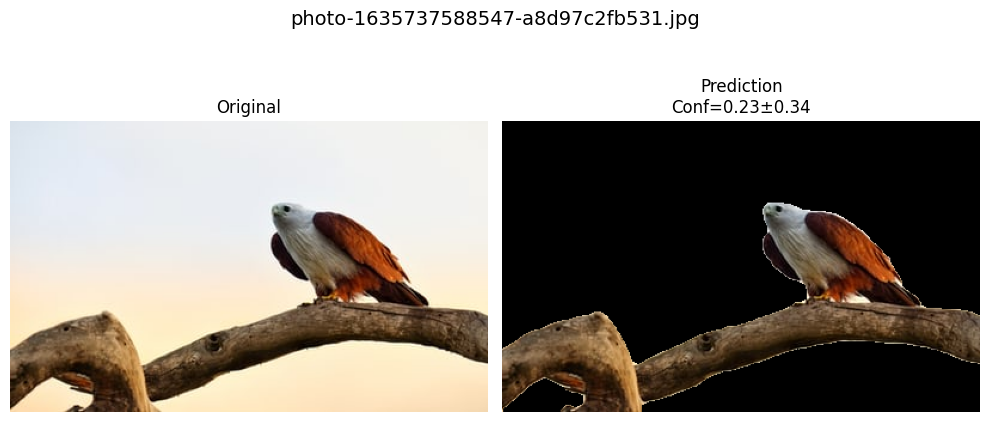

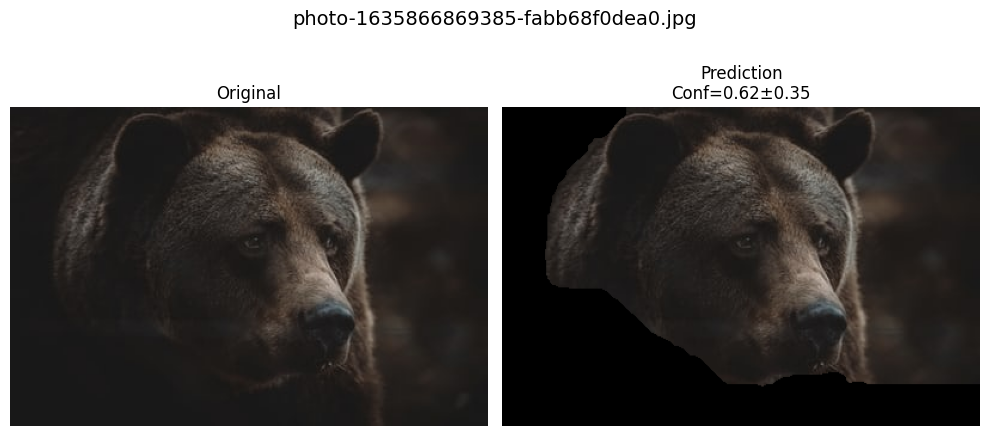

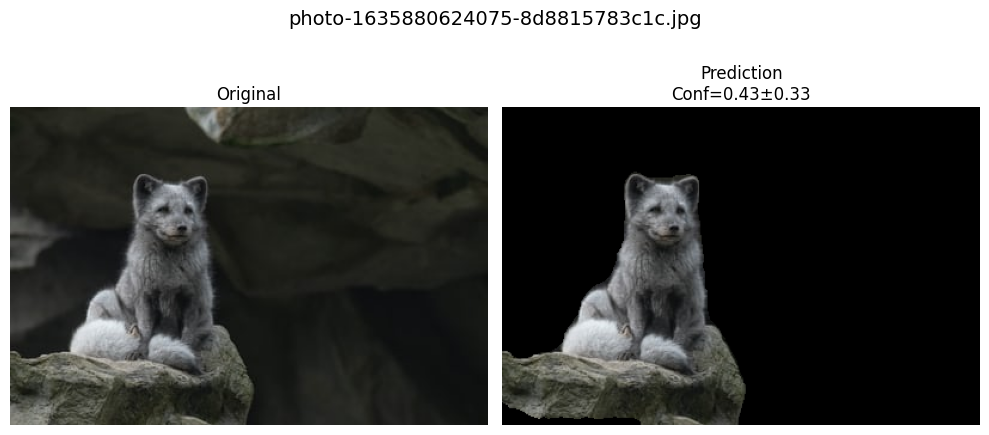

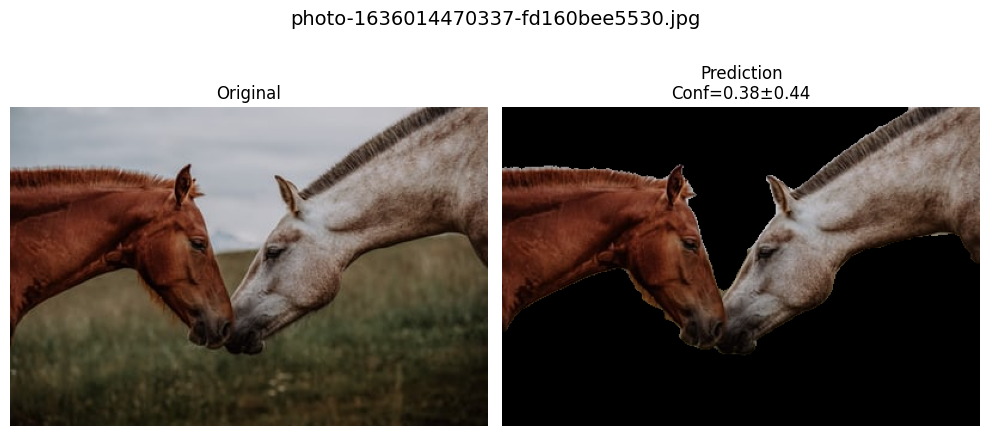

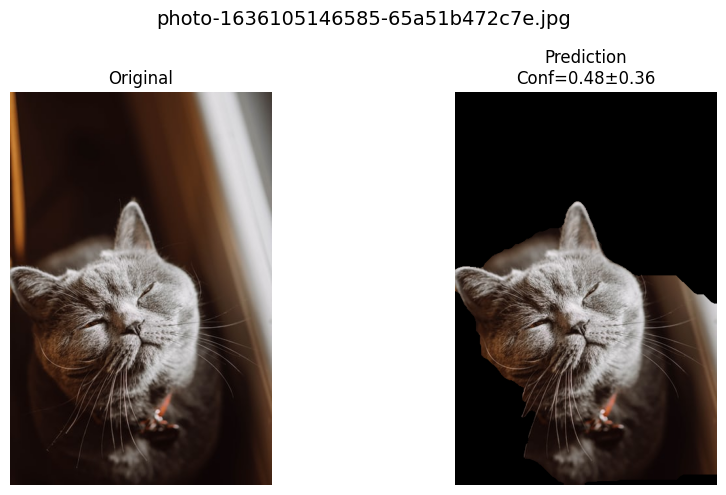

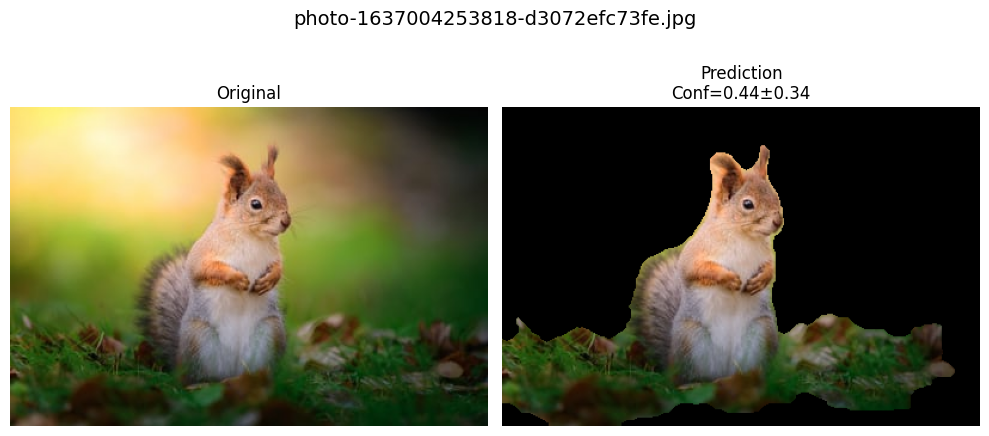

In [15]:
# inference_unseen_all_jupyter.ipynb cell

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.segmentation import deeplabv3_resnet101
import torchvision.transforms.functional as TF

# ---------------------- CONFIG ----------------------
MODEL_PATH = r"C:\Users\rahul\Downloads\Telegram Desktop\deeplabv3_resnet101_stage3_full.pth"
IMAGE_DIR  = r"C:\Users\rahul\Downloads\unseendata"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
INPUT_SIZE = 640
# Enhanced TTA configuration
TTA_SCALES = [0.5, 0.75, 1.0, 1.25, 1.5]
DO_FLIP = True
GRABCUT_ITERS = 8  

print("Device:", DEVICE)

# ---------------------- model helpers ----------------------
def replace_bn_with_gn(module, num_groups=32):
    for name, child in list(module.named_children()):
        if isinstance(child, nn.BatchNorm2d):
            setattr(module, name, nn.GroupNorm(num_groups=num_groups, num_channels=child.num_features))
        else:
            replace_bn_with_gn(child, num_groups)

def build_model(num_classes=1):
    model = deeplabv3_resnet101(weights=None, aux_loss=False)
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    replace_bn_with_gn(model)
    return model

def safe_load_checkpoint_into_model(model, ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    sd = ckpt.get("state_dict", ckpt) if isinstance(ckpt, dict) else ckpt
    model_sd = model.state_dict()
    filtered = {k.replace("module.",""): v for k,v in sd.items() if k.replace("module.","") in model_sd and model_sd[k.replace("module.","")].shape==v.shape}
    msg = model.load_state_dict(filtered, strict=False)
    print(f"Loaded {len(filtered)} keys. Missing: {len(msg.missing_keys)} Unexpected: {len(msg.unexpected_keys)}")

model = build_model(num_classes=1)
safe_load_checkpoint_into_model(model, MODEL_PATH)
model.to(DEVICE).eval()

# ---------------------- preprocess ----------------------
def resize_keep_aspect_and_pad(pil_img, min_short=INPUT_SIZE, scale=1.0, pad_fill=(0,0,0), max_side=1280):
    w, h = pil_img.size
    base_scale = min_short / float(min(w, h))
    tw, th = int(w*base_scale*scale), int(h*base_scale*scale)
    if max(tw,th) > max_side:
        ratio = max_side / float(max(tw,th))
        tw, th = int(tw*ratio), int(th*ratio)
    img_resized = pil_img.resize((tw, th), Image.BILINEAR)
    S = max(tw, th)
    canvas = Image.new("RGB",(S,S), pad_fill)
    l,t = (S-tw)//2, (S-th)//2
    canvas.paste(img_resized,(l,t))
    return canvas,(l,t,tw,th,S)

def tensor_from_pil(img):
    t = TF.to_tensor(img)
    return TF.normalize(t, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]).unsqueeze(0)

def upsample_to(x,h,w): 
    return F.interpolate(x,size=(h,w),mode="bilinear",align_corners=False)

# ---------------------- IMPROVED POSTPROCESSING ----------------------
def improved_adaptive_threshold(prob_map):
    vals = prob_map.flatten()
    m = vals.mean()
    s = vals.std()
    stat_thresh = max(0.15, min(0.7, m + 0.3 * s))
    p90 = np.percentile(vals, 90)
    p10 = np.percentile(vals, 10)
    percentile_thresh = p10 + 0.4 * (p90 - p10)
    hist, bins = np.histogram(vals, bins=128, range=(0, 1))
    bin_centers = (bins[:-1] + bins[1:]) / 2
    high_prob_indices = hist > np.percentile(hist, 70)
    if np.any(high_prob_indices):
        high_prob_centers = bin_centers[high_prob_indices]
        high_prob_weights = hist[high_prob_indices]
        weighted_thresh = np.average(high_prob_centers, weights=high_prob_weights)
    else:
        weighted_thresh = 0.5
    final_thresh = (0.4 * stat_thresh + 0.4 * percentile_thresh + 0.2 * weighted_thresh)
    final_thresh = max(0.1, min(0.8, final_thresh))
    return final_thresh, float(m), float(s)

def improved_morphology(mask):
    if np.sum(mask) == 0:
        return mask
    mask = (mask > 0).astype(np.uint8)
    h, w = mask.shape
    k_small = max(3, min(7, int(min(h, w) / 150)))
    k_medium = max(5, min(11, int(min(h, w) / 100)))
    k_small = k_small + 1 if k_small % 2 == 0 else k_small
    k_medium = k_medium + 1 if k_medium % 2 == 0 else k_medium
    kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_small, k_small))
    kernel_medium = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_medium, k_medium))
    m = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_small, iterations=1)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel_small, iterations=1)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel_medium, iterations=2)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if num_labels <= 1:
        return m
    areas = stats[1:, cv2.CC_STAT_AREA]
    if len(areas) == 0:
        return m
    max_area = np.max(areas)
    result = np.zeros_like(m)
    for i in range(1, num_labels):
        if areas[i-1] >= max_area * 0.08:
            result[labels == i] = 1
    return result

def improved_grabcut_refine(orig, mask, prob_map, iters=8):
    if np.sum(mask) < 15:
        return mask
    img = cv2.cvtColor(np.array(orig), cv2.COLOR_RGB2BGR)
    h, w = mask.shape
    gc_mask = np.full((h, w), cv2.GC_PR_BGD, np.uint8)
    gc_mask[prob_map > 0.85] = cv2.GC_FGD
    gc_mask[(prob_map > 0.45) & (prob_map <= 0.85)] = cv2.GC_PR_FGD
    gc_mask[(prob_map >= 0.15) & (prob_map <= 0.45)] = cv2.GC_PR_BGD
    gc_mask[prob_map < 0.15] = cv2.GC_BGD
    fg_count = np.sum((gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD))
    bg_count = np.sum((gc_mask == cv2.GC_BGD) | (gc_mask == cv2.GC_PR_BGD))
    if fg_count < 30 or bg_count < 30:
        gc_mask[mask == 1] = cv2.GC_PR_FGD
        gc_mask[mask == 0] = cv2.GC_PR_BGD
    try:
        bgd_model = np.zeros((1, 65), np.float64)
        fgd_model = np.zeros((1, 65), np.float64)
        cv2.grabCut(img, gc_mask, None, bgd_model, fgd_model, iters, cv2.GC_INIT_WITH_MASK)
        refined_mask = np.where((gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD), 1, 0)
        return refined_mask.astype(np.uint8)
    except Exception:
        return mask

def run_one_pass(orig, scale=1.0, flip=False):
    canvas, (l, t, tw, th, S) = resize_keep_aspect_and_pad(orig, INPUT_SIZE, scale)
    if flip: 
        canvas = TF.hflip(canvas)
    inp = tensor_from_pil(canvas).to(DEVICE)
    with torch.no_grad():
        out = model(inp)["out"]
        out = upsample_to(out, S, S)
        p = torch.sigmoid(out)[0, 0].cpu().numpy()
    if flip: 
        p = np.fliplr(p)
    pc = p[t:t+th, l:l+tw]
    return cv2.resize(pc, (orig.width, orig.height), cv2.INTER_LINEAR)

# ---------------------- IMPROVED TTA PREDICT ----------------------
def enhanced_tta_predict(orig):
    H, W = orig.height, orig.width
    acc = np.zeros((H, W), np.float32)
    c = 0
    for s in TTA_SCALES:
        for flip in [False, True] if DO_FLIP else [False]:
            prob_map = run_one_pass(orig, s, flip)
            acc += prob_map
            c += 1
    avg = acc / c
    thr, mc, sc = improved_adaptive_threshold(avg)
    mask = (avg > thr).astype(np.uint8)
    mask = improved_morphology(mask)
    mask = improved_grabcut_refine(orig, mask, avg)
    mask = improved_morphology(mask)
    return np.array(orig), (mask[..., None] * np.array(orig)).astype(np.uint8), mc, sc

# ---------------------- Run on ALL unseen images ----------------------
all_imgs = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(("jpg", "png", "jpeg"))]

for fname in all_imgs:
    path = os.path.join(IMAGE_DIR, fname)
    img = Image.open(path).convert("RGB")
    orig, res, mc, sc = enhanced_tta_predict(img)
    
    # Larger figure size for better visualization
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))  
    
    axs[0].imshow(orig)
    axs[0].set_title("Original", fontsize=12)
    axs[0].axis("off")

    axs[1].imshow(res)
    axs[1].set_title(f"Prediction\nConf={mc:.2f}±{sc:.2f}", fontsize=12)
    axs[1].axis("off")

    plt.suptitle(fname, fontsize=14)
    plt.tight_layout()
    plt.show()
